# Molecular Shape Conditioning: Coordinate Eigenvalues Demonstration

This notebook demonstrates how to compute and visualize **associated shape-conditioning eigenvalues** for molecules. 

It is designed to be **fully self-contained**—it will generate and process synthetic molecules (linear, planar, and 3D) on the fly, and will optionally load the preprocessed QM9/GEOM-Drugs datasets if they are available.

## Background: What are Coordinate Eigenvalues?
For a molecule with $N$ atom positions represented by the coordinates matrix $X \in \mathbb{R}^{N 	imes 3}$:
1. **Center of Mass / Mean Centering**: We translate the coordinates to the center of mass:
   $$X_c = X - \frac{1}{N} \sum_{i=1}^N X_i$$
   where $X_c \in \mathbb{R}^{N 	imes 3}$.
2. **Covariance Matrix**: We compute the $3 	imes 3$ coordinate covariance matrix:
   $$C = \frac{1}{N} X_c^T X_c$$
   Alternatively, we can compute the unnormalized Gram matrix $G = X_c^T X_c$, which is $N$ times the covariance.
3. **Eigendecomposition**: Since $C$ is a symmetric positive semi-definite matrix, we perform eigendecomposition to find its 3 real eigenvalues:
   $$\lambda_1 \ge \lambda_2 \ge \lambda_3 \ge 0$$
   and their corresponding eigenvectors $v_1, v_2, v_3$.

## Why is this useful for Shape Conditioning?
* **Rotational and Translational Invariance**: Eigendecomposition is invariant to translation (since we mean-center) and rotation (rotating coordinates rotates the eigenvectors but keeps the eigenvalues identical).
* **Geometric Meaning**: The eigenvalues represent the variance of the atom coordinates along the three principal axes (the eigenvectors).
  * **Linear Molecules**: $\lambda_1 > 0$, while $\lambda_2 \approx \lambda_3 \approx 0$.
  * **Planar Molecules**: $\lambda_1 \ge \lambda_2 > 0$, while $\lambda_3 \approx 0$.
  * **3D Spherical/Globular Molecules**: $\lambda_1 \approx \lambda_2 \approx \lambda_3 > 0$.


In [1]:
import os
import torch
import numpy as np
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt

# Periodic table mapping for QM9 / GEOM-Drugs / Synthetic
ATOM_MAP = {
    1: {'symbol': 'H', 'color': 'white', 'size': 8},
    6: {'symbol': 'C', 'color': 'gray', 'size': 12},
    7: {'symbol': 'N', 'color': 'blue', 'size': 12},
    8: {'symbol': 'O', 'color': 'red', 'size': 12},
    9: {'symbol': 'F', 'color': 'green', 'size': 12},
    15: {'symbol': 'P', 'color': 'orange', 'size': 14},
    16: {'symbol': 'S', 'color': 'yellow', 'size': 14},
    17: {'symbol': 'Cl', 'color': 'darkgreen', 'size': 14},
    35: {'symbol': 'Br', 'color': 'brown', 'size': 15},
    53: {'symbol': 'I', 'color': 'purple', 'size': 16}
}


def compute_eigenvalues_and_axes(pos: torch.Tensor):
    """
    Computes both unnormalized and normalized eigenvalues, 
    along with eigenvectors (principal axes) for a coordinate tensor.
    """
    # Mean centering
    com = pos.mean(dim=0, keepdim=True)
    pos_centered = pos - com
    
    # Covariance matrices
    cov_unnorm = torch.matmul(pos_centered.T, pos_centered)
    cov_norm = cov_unnorm / pos.size(0)
    
    # Eigendecomposition for normalized
    e_norm, v = torch.linalg.eigh(cov_norm)
    # Sort in descending order
    idx = torch.argsort(e_norm, descending=True)
    e_norm = e_norm[idx]
    v = v[:, idx]
    
    # Eigendecomposition for unnormalized
    e_unnorm, _ = torch.linalg.eigh(cov_unnorm)
    e_unnorm = torch.sort(e_unnorm, descending=True).values
    
    # Clamp negative values to zero (numerical precision)
    e_norm = torch.clamp(e_norm, min=0.0)
    e_unnorm = torch.clamp(e_unnorm, min=0.0)
    
    return {
        'com': com.squeeze(0),
        'eigenvalues_unnorm': e_unnorm,
        'eigenvalues_norm': e_norm,
        'eigenvectors': v
    }


def visualize_molecule_shape_axes(pos: torch.Tensor, atomic_numbers: torch.Tensor, title_prefix=""):
    """
    Visualizes a molecule in 3D using Plotly, adding arrows/lines for 
    the principal shape axes scaled by the standard deviation (sqrt of eigenvalues).
    """
    # Compute shape descriptors
    results = compute_eigenvalues_and_axes(pos)
    com = results['com'].numpy()
    e_norm = results['eigenvalues_norm'].numpy()
    e_unnorm = results['eigenvalues_unnorm'].numpy()
    v = results['eigenvectors'].numpy()
    
    pos_np = pos.numpy()
    atomic_nums_np = atomic_numbers.numpy()
    
    # Map elements
    symbols = [ATOM_MAP.get(num, {'symbol': 'X', 'color': 'magenta', 'size': 12})['symbol'] for num in atomic_nums_np]
    colors = [ATOM_MAP.get(num, {'symbol': 'X', 'color': 'magenta', 'size': 12})['color'] for num in atomic_nums_np]
    sizes = [ATOM_MAP.get(num, {'symbol': 'X', 'color': 'magenta', 'size': 12})['size'] for num in atomic_nums_np]
    
    # 1. Create Atom Trace
    atom_trace = go.Scatter3d(
        x=pos_np[:, 0],
        y=pos_np[:, 1],
        z=pos_np[:, 2],
        mode='markers+text',
        text=symbols,
        textposition='top center',
        marker=dict(
            size=sizes,
            color=colors,
            line=dict(width=1.5, color='black')
        ),
        name='Atoms'
    )
    
    # 2. Create Bond Traces (threshold heuristic)
    bond_traces = []
    n = len(pos_np)
    for i in range(n):
        for j in range(i + 1, n):
            dist = np.linalg.norm(pos_np[i] - pos_np[j])
            threshold = 1.6
            if symbols[i] == 'H' or symbols[j] == 'H':
                threshold = 1.2
            if dist <= threshold:
                bond_traces.append(go.Scatter3d(
                    x=[pos_np[i, 0], pos_np[j, 0]],
                    y=[pos_np[i, 1], pos_np[j, 1]],
                    z=[pos_np[i, 2], pos_np[j, 2]],
                    mode='lines',
                    line=dict(color='black', width=3.5),
                    showlegend=False,
                    hoverinfo='none'
                ))
                
    # 3. Create Principal Axes Traces (scaled by standard deviations)
    axis_colors = ['red', 'green', 'blue'] # Primary, secondary, tertiary axes
    axis_traces = []
    
    for i in range(3):
        std_dev = np.sqrt(e_norm[i])
        axis_vector = v[:, i]
        # Length of axis to plot (2 standard deviations)
        length = 2.0 * std_dev
        end_point = com + length * axis_vector
        
        # Line trace
        axis_traces.append(go.Scatter3d(
            x=[com[0], end_point[0]],
            y=[com[1], end_point[1]],
            z=[com[2], end_point[2]],
            mode='lines+text',
            text=['', f'Axis {i+1} (λ_norm={e_norm[i]:.2f})'],
            textposition='top center',
            line=dict(color=axis_colors[i], width=6),
            name=f'Axis {i+1}'
        ))
        
    # Center of mass trace
    com_trace = go.Scatter3d(
        x=[com[0]],
        y=[com[1]],
        z=[com[2]],
        mode='markers',
        marker=dict(color='gold', size=10, symbol='diamond'),
        name='Center of Mass'
    )
        
    title = f"{title_prefix}<br>Eigenvalues: Unnorm = [{e_unnorm[0]:.2f}, {e_unnorm[1]:.2f}, {e_unnorm[2]:.2f}], Norm = [{e_norm[0]:.2f}, {e_norm[1]:.2f}, {e_norm[2]:.2f}]"
    
    fig = go.Figure(data=[atom_trace, com_trace] + bond_traces + axis_traces)
    fig.update_layout(
        scene=dict(
            xaxis=dict(title='X (Å)', showgrid=True),
            yaxis=dict(title='Y (Å)', showgrid=True),
            zaxis=dict(title='Z (Å)', showgrid=True),
            aspectmode='data'
        ),
        title=title,
        width=850,
        height=600
    )
    return fig


def get_synthetic_molecule(shape_type: str):
    """
    Generates coordinates and atomic numbers for synthetic molecules
    to demonstrate the eigenvalue calculations without any datasets.
    """
    if shape_type == 'linear':
        # Carbon Dioxide (CO2) - Linear
        pos = torch.tensor([
            [-1.16, 0.0, 0.0],  # Oxygen
            [0.0, 0.0, 0.0],    # Carbon
            [1.16, 0.0, 0.0]    # Oxygen
        ], dtype=torch.float32)
        h = torch.tensor([8, 6, 8], dtype=torch.long)
        name = "Synthetic Carbon Dioxide (Linear)"
        
    elif shape_type == 'planar':
        # Benzene (C6H6) - Flat hexagon
        pos_list = []
        h_list = []
        r_cc = 1.40  # C-C bond radius
        r_ch = 2.48  # C-H radius from COM
        
        for i in range(6):
            angle = i * (np.pi / 3)
            # Carbon
            pos_list.append([r_cc * np.cos(angle), r_cc * np.sin(angle), 0.0])
            h_list.append(6)
            # Hydrogen
            pos_list.append([r_ch * np.cos(angle), r_ch * np.sin(angle), 0.0])
            h_list.append(1)
            
        pos = torch.tensor(pos_list, dtype=torch.float32)
        h = torch.tensor(h_list, dtype=torch.long)
        name = "Synthetic Benzene (Planar)"
        
    elif shape_type == 'globular':
        # Methane (CH4) - Tetrahedral 3D shape
        pos = torch.tensor([
            [0.0, 0.0, 0.0],        # Carbon
            [0.63, 0.63, 0.63],     # Hydrogen
            [-0.63, -0.63, 0.63],   # Hydrogen
            [-0.63, 0.63, -0.63],   # Hydrogen
            [0.63, -0.63, -0.63]    # Hydrogen
        ], dtype=torch.float32)
        h = torch.tensor([6, 1, 1, 1, 1], dtype=torch.long)
        name = "Synthetic Methane (3D Globular)"
        
    else:
        raise ValueError(f"Unknown shape type: {shape_type}")
        
    return pos, h, name



In [2]:
# Run the eigenvalue shape processing and visualization for the generated shapes
# 1. Linear shape
pos, h, name = get_synthetic_molecule('linear')
fig_linear = visualize_molecule_shape_axes(pos, h, name)
fig_linear.show()

# 2. Planar shape
pos, h, name = get_synthetic_molecule('planar')
fig_planar = visualize_molecule_shape_axes(pos, h, name)
fig_planar.show()

# 3. 3D Globular shape
pos, h, name = get_synthetic_molecule('globular')
fig_globular = visualize_molecule_shape_axes(pos, h, name)
fig_globular.show()


In [3]:
# Load preprocessed dataset files if they exist on disk (GEOM-Drugs Train Set)
geom_train_path = '../data/geom_drugs/preprocessed/train.pt'
dataset_loaded = False
geom_train = []

if os.path.exists(geom_train_path):
    try:
        geom_train = torch.load(geom_train_path)
        print(f"Success: Loaded {len(geom_train)} GEOM molecules from {geom_train_path}!")
        dataset_loaded = True
    except Exception as e:
        print(f"Could not load dataset file: {e}")
else:
    print(f"Dataset file {geom_train_path} not found. Skipping dataset demonstration.")

if dataset_loaded:
    # Let's find a planar and a globular molecule in the real dataset
    planar_mol = None
    globular_mol = None
    
    for mol in geom_train:
        e = getattr(mol, 'eigenvalues_normalized', getattr(mol, 'eigenvalues', None))
        if e is None:
            continue
        n_atoms = mol.pos.size(0)
        
        # Planar definition: 3rd eigenvalue is tiny, 2nd is substantial
        if e[2] < 1e-4 and e[1] > 0.05 and n_atoms > 3 and planar_mol is None:
            planar_mol = mol
        # 3D definition: 3rd eigenvalue is large
        if e[2] > 0.15 and globular_mol is None:
            globular_mol = mol
            
    # Visualize Planar Molecule from dataset
    if planar_mol is not None:
        fig = visualize_molecule_shape_axes(planar_mol.pos, planar_mol.h, "Real Planar Molecule (GEOM Train)")
        fig.show()
        
    # Visualize Globular Molecule from dataset
    if globular_mol is not None:
        fig = visualize_molecule_shape_axes(globular_mol.pos, globular_mol.h, "Real 3D Molecule (GEOM Train)")
        fig.show()


Success: Loaded 93287 GEOM molecules from ../data/geom_drugs/preprocessed/train.pt!


First 10 example values of eigenvalues_no_h_normalized (sorted lambda_1 >= lambda_2 >= lambda_3):
  Molecule 1: [9.273225784301758, 3.396385431289673, 0.5426638126373291]
  Molecule 2: [10.585649490356445, 1.3968021869659424, 0.47484660148620605]
  Molecule 3: [6.550926208496094, 2.337552547454834, 0.5402553677558899]
  Molecule 4: [4.857954978942871, 2.354665994644165, 0.3702927827835083]
  Molecule 5: [5.160196781158447, 3.0288448333740234, 0.17024244368076324]
  Molecule 6: [7.225897789001465, 2.455352783203125, 1.093847632408142]
  Molecule 7: [5.299750804901123, 3.1985995769500732, 0.25606948137283325]
  Molecule 8: [5.856143951416016, 2.8881170749664307, 1.328939437866211]
  Molecule 9: [8.271912574768066, 0.8340215682983398, 0.16713494062423706]
  Molecule 10: [13.328319549560547, 2.2341485023498535, 0.4320983290672302]


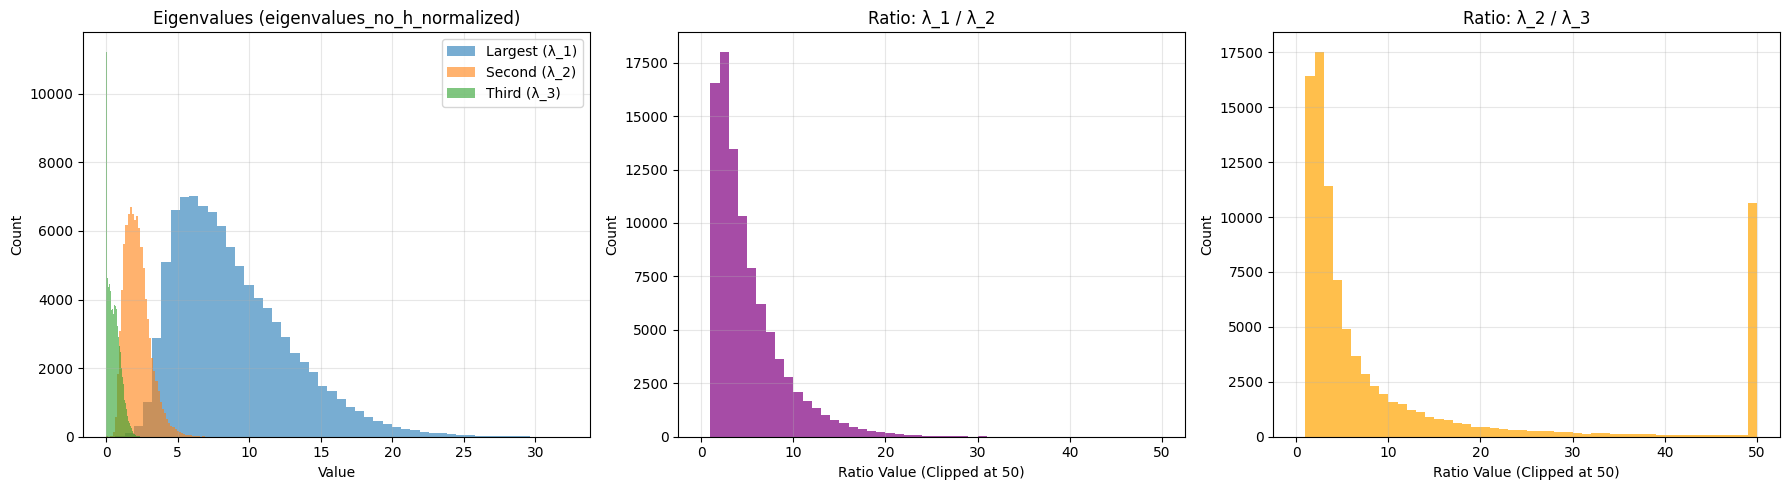

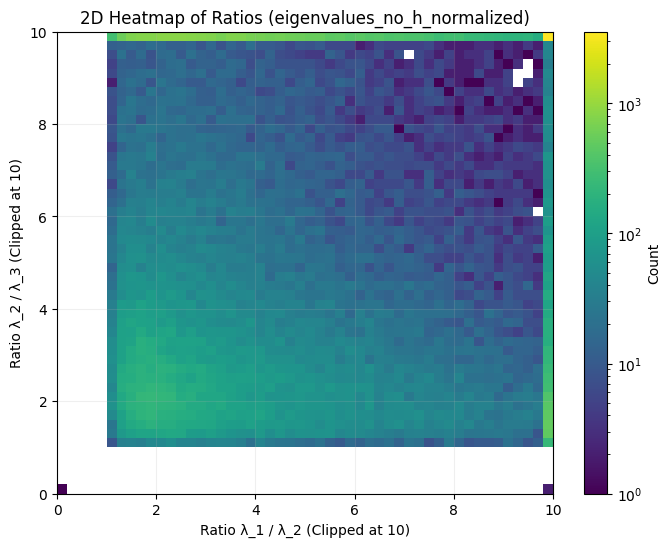

In [4]:
from matplotlib.colors import LogNorm
if dataset_loaded:
    # Set the attribute name to visualize. Options include:
    # - 'eigenvalues_normalized' (normalized eigenvalues, including H)
    # - 'eigenvalues_normalized_no_h' (normalized eigenvalues, excluding H)
    # - 'eigenvalues' or 'eigenvalues_unnorm' (unnormalized eigenvalues, including H)
    # - 'eigenvalues_unnorm_no_h' (unnormalized eigenvalues, excluding H - computed on the fly)
    target_attribute = 'eigenvalues_no_h_normalized'
    
    # Map alternative names to precalculated dataset attribute if possible to avoid on-the-fly computation
    dataset_attribute = target_attribute
    if target_attribute in ['eigenvalues_no_h_normalized', 'eigenvalues_no_h_normalzied']:
        dataset_attribute = 'eigenvalues_normalized_no_h'
    
    e_list = []
    for mol in geom_train:
        e = getattr(mol, dataset_attribute, None)
        # If the attribute doesn't exist or is custom (like unnorm_no_h), compute on the fly
        if e is None:
            if 'no_h' in dataset_attribute:
                mask_no_h = mol.h != 1
                pos = mol.pos[mask_no_h]
            else:
                pos = mol.pos
                
            if pos.size(0) > 0:
                res = compute_eigenvalues_and_axes(pos)
                if 'normalized' in dataset_attribute or 'norm' in dataset_attribute:
                    e = res['eigenvalues_norm']
                else:
                    e = res['eigenvalues_unnorm']
            else:
                e = torch.zeros(3)
                
        e_list.append(e.numpy() if isinstance(e, torch.Tensor) else e)
        
    e_arr = np.array(e_list)
    # Ensure eigenvalues are sorted: lambda_1 >= lambda_2 >= lambda_3
    e_arr = np.sort(e_arr, axis=1)[:, ::-1]

    # Print 10 example values of target_attribute as requested
    print(f'First 10 example values of {target_attribute} (sorted lambda_1 >= lambda_2 >= lambda_3):')
    for idx, e_val in enumerate(e_arr[:10]):
        print(f'  Molecule {idx+1}: {e_val.tolist()}')

    # Calculate ratios (adding epsilon to avoid division by zero)
    eps = 1e-8
    ratio_1_2 = e_arr[:, 0] / (e_arr[:, 1] + eps)
    ratio_2_3 = e_arr[:, 1] / (e_arr[:, 2] + eps)

    # Note: 'reduce the number of blocks to a more reasonable number, fx 5 in total.'
    # We set bins=50 for reasonable density in the histograms
    n_bins = 50

    # 1. 1D Histograms
    fig, axs = plt.subplots(1, 3, figsize=(18, 5), dpi=100)
    
    # 1a. Basic size of eigenvalues
    axs[0].hist(e_arr[:, 0], bins=n_bins, alpha=0.6, label='Largest (λ_1)')
    axs[0].hist(e_arr[:, 1], bins=n_bins, alpha=0.6, label='Second (λ_2)')
    axs[0].hist(e_arr[:, 2], bins=n_bins, alpha=0.6, label='Third (λ_3)')
    axs[0].set_title(f'Eigenvalues ({target_attribute})')
    axs[0].set_xlabel('Value')
    axs[0].set_ylabel('Count')
    axs[0].legend()
    axs[0].grid(True, alpha=0.3)

    # 1b. Ratio: Largest / Second Largest
    # Clip large ratio values for better visualization
    axs[1].hist(np.clip(ratio_1_2, 0, 50), bins=n_bins, alpha=0.7, color='purple')
    axs[1].set_title('Ratio: λ_1 / λ_2')
    axs[1].set_xlabel('Ratio Value (Clipped at 50)')
    axs[1].set_ylabel('Count')
    axs[1].grid(True, alpha=0.3)

    # 1c. Ratio: Second Largest / Third Largest
    axs[2].hist(np.clip(ratio_2_3, 0, 50), bins=n_bins, alpha=0.7, color='orange')
    axs[2].set_title('Ratio: λ_2 / λ_3')
    axs[2].set_xlabel('Ratio Value (Clipped at 50)')
    axs[2].set_ylabel('Count')
    axs[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    # 2. 2D Heatmap (Histogram) of Ratios
    plt.figure(figsize=(8, 6), dpi=100)
    # Clip values to 20 for a better 2D heat map view (adjust as necessary)
    max_ratio_plot = 10
    x_vals = np.clip(ratio_1_2, 0, max_ratio_plot)
    y_vals = np.clip(ratio_2_3, 0, max_ratio_plot)
    
    h2d = plt.hist2d(x_vals, y_vals, bins=50, cmap='viridis', norm=LogNorm())
    plt.colorbar(h2d[3], label='Count')
    plt.title(f'2D Heatmap of Ratios ({target_attribute})')
    plt.xlabel('Ratio λ_1 / λ_2 (Clipped at 10)')
    plt.ylabel('Ratio λ_2 / λ_3 (Clipped at 10)')
    plt.grid(True, alpha=0.2)
    plt.show()

else:
    print("Dataset distribution plot skipped because no preprocessed dataset was loaded.")
